# 05 - Treino Logistic Regression (NumPy)

Regressão logística multinomial em NumPy com `TF-IDF` word-level.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Random search com `build_random_search` de `src/hyperopt.py`


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.hyperopt import build_random_search
from src.models_numpy.logistic_regression import LogisticRegression
from src.vectorizer import create_vectorizer


In [3]:
# Configuração
SEED = 42
N_ITERATIONS = 20
np.random.seed(SEED)


## 1. Carregamento de Dados

In [4]:
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text)
    return df


def one_hot(labels, n_classes=NUM_CLASSES):
    return np.eye(n_classes)[labels]


df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')


Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
Train: 2566 amostras
  Labels: {'Human': 567, 'Meta': 555, 'Google': 525, 'Anthropic': 488, 'OpenAI': 431}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


## 2. Espaço de Busca

In [5]:
param_grid = {
    'max_words': [1000, 1500, 2000, 3000],
    'learning_rate': [0.01, 0.05, 0.1],
    'epochs': [500, 700, 900],
}

print('Opções por parâmetro:')
for k, v in param_grid.items():
    print(f'  {k}: {len(v)} opções')


Opções por parâmetro:
  max_words: 4 opções
  learning_rate: 3 opções
  epochs: 3 opções


## 3. Funções de Treino

In [6]:
def stratified_split_indices(labels, train_ratio=0.8, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)
    train_idx, val_idx = [], []
    for label in np.unique(labels):
        cls_idx = np.where(labels == label)[0]
        cls_idx = rng.permutation(cls_idx)
        split = int(train_ratio * len(cls_idx))
        train_idx.extend(cls_idx[:split])
        val_idx.extend(cls_idx[split:])
    return np.array(train_idx), np.array(val_idx)


def train_logreg(params, df_train):
    train_idx, val_idx = stratified_split_indices(df_train['label_id'].values)
    df_tr = df_train.iloc[train_idx].reset_index(drop=True)
    df_te = df_train.iloc[val_idx].reset_index(drop=True)

    vectorizer = create_vectorizer('word', max_words=params['max_words'])
    X_tr = vectorizer.fit_transform(list(df_tr['text_clean']))
    X_te = vectorizer.transform(list(df_te['text_clean']))

    y_tr = one_hot(df_tr['label_id'].values)
    y_te = one_hot(df_te['label_id'].values)

    model = LogisticRegression(
        n_features=X_tr.shape[1],
        n_classes=NUM_CLASSES,
        learning_rate=params['learning_rate'],
        epochs=params['epochs'],
    )

    t0 = time.time()
    history = model.fit(X_tr, y_tr, val_data=(X_te, y_te), verbose=False)
    train_time = time.time() - t0

    val_acc = max(history['val_acc']) if history['val_acc'] else 0
    train_acc = max(history['train_acc']) if history['train_acc'] else 0
    return model, vectorizer, val_acc, train_acc, history, train_time


def evaluate_external(model, vectorizer, df_ext):
    X = vectorizer.transform(list(df_ext['text_clean']))
    labels = df_ext['label_id'].values
    probs = model.predict_proba(X)
    preds = np.argmax(probs, axis=1)
    return accuracy_score(labels, preds)


def full_evaluation(model, vectorizer, df_ext, name):
    X = vectorizer.transform(list(df_ext['text_clean']))
    labels = df_ext['label_id'].values
    probs = model.predict_proba(X)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Greens')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()
    plt.show()
    return probs, labels


## 4. Random Search

In [7]:
results = []
best_internal_val = -1
best_model = None
best_vectorizer = None
best_params = None

print(f'=== Random Search: Logistic Regression — {N_ITERATIONS} iterações ===')
print()

for i, params in enumerate(build_random_search(param_grid, n_iter=N_ITERATIONS, random_state=SEED), start=1):
    print(f'[{i}/{N_ITERATIONS}] max_words={params["max_words"]} lr={params["learning_rate"]} epochs={params["epochs"]}')
    try:
        model, vectorizer, val_acc, train_acc, history, train_time = train_logreg(params, df_train)
        val1_acc = evaluate_external(model, vectorizer, df_val1)
        val2_acc = evaluate_external(model, vectorizer, df_val2)
        print(f'  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)')

        results.append({
            'iteration': i,
            'max_words': params['max_words'],
            'learning_rate': params['learning_rate'],
            'epochs': params['epochs'],
            'internal_val': val_acc,
            'train_acc': train_acc,
            'val1_acc': val1_acc,
            'val2_acc': val2_acc,
            'train_time': train_time,
        })

        if val_acc > best_internal_val:
            best_internal_val = val_acc
            best_model = model
            best_vectorizer = vectorizer
            best_params = params.copy()
            print('  *** NOVO MELHOR INTERNO ***')
    except Exception as e:
        print(f'  -> ERRO: {e}')
        results.append({'iteration': i, 'error': str(e)})

print('\n=== Concluído ===')


=== Random Search: Logistic Regression — 20 iterações ===

[1/20] max_words=1000 lr=0.01 epochs=900
  -> internal=0.2816 | val1=0.4160 | val2=0.3400 (6.3s)
  *** NOVO MELHOR INTERNO ***
[2/20] max_words=2000 lr=0.01 epochs=500
  -> internal=0.2641 | val1=0.4160 | val2=0.3400 (5.2s)
[3/20] max_words=1500 lr=0.1 epochs=500
  -> internal=0.4019 | val1=0.4400 | val2=0.3600 (3.7s)
  *** NOVO MELHOR INTERNO ***
[4/20] max_words=1000 lr=0.1 epochs=700
  -> internal=0.4175 | val1=0.4400 | val2=0.3700 (4.2s)
  *** NOVO MELHOR INTERNO ***
[5/20] max_words=1000 lr=0.01 epochs=500
  -> internal=0.2427 | val1=0.4160 | val2=0.3400 (2.6s)
[6/20] max_words=1500 lr=0.01 epochs=900
  -> internal=0.2951 | val1=0.4160 | val2=0.3400 (9.0s)
[7/20] max_words=1000 lr=0.1 epochs=500
  -> internal=0.4000 | val1=0.4400 | val2=0.3700 (3.5s)
[8/20] max_words=3000 lr=0.01 epochs=700
  -> internal=0.2893 | val1=0.4160 | val2=0.3400 (17.7s)
[9/20] max_words=2000 lr=0.01 epochs=500
  -> internal=0.2641 | val1=0.4160 |

## 5. Resultados

In [8]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]
results_df = results_df.sort_values('internal_val', ascending=False).reset_index(drop=True)

print('=== Top 5 Modelos (por internal_val) ===')
print(results_df.head(5)[[
    'iteration', 'max_words', 'learning_rate', 'epochs', 'internal_val', 'val1_acc', 'val2_acc'
]].to_string(index=False))


=== Top 5 Modelos (por internal_val) ===
 iteration  max_words  learning_rate  epochs  internal_val  val1_acc  val2_acc
        17       2000           0.10     900      0.452427      0.44      0.38
         4       1000           0.10     700      0.417476      0.44      0.37
        15       3000           0.10     500      0.409709      0.44      0.36
        18       2000           0.10     500      0.409709      0.44      0.36
        10       3000           0.05     700      0.403883      0.44      0.36


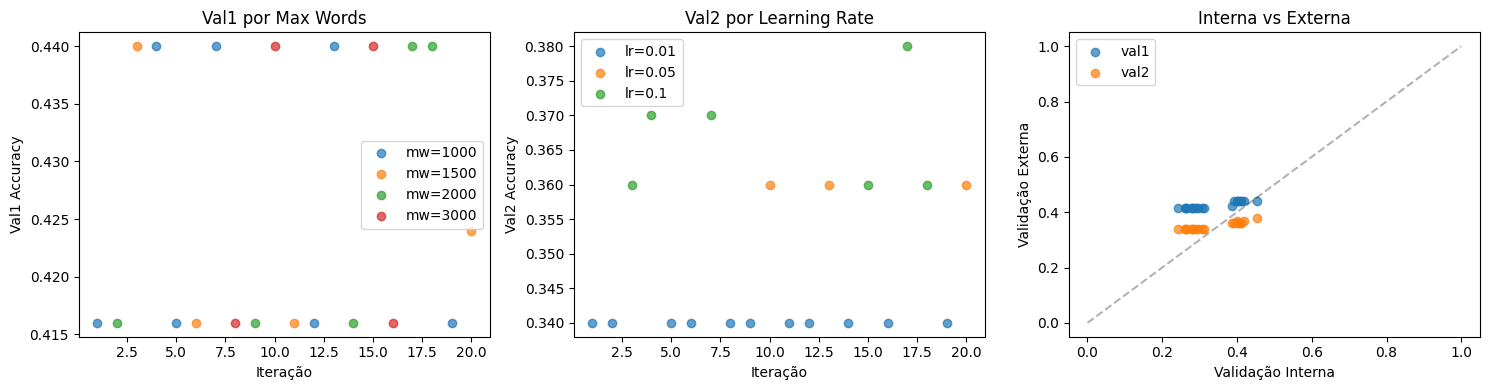

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for mw in sorted(results_df['max_words'].unique()):
    mask = results_df['max_words'] == mw
    axes[0].scatter(results_df[mask]['iteration'], results_df[mask]['val1_acc'], label=f'mw={mw}', alpha=0.7)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 por Max Words')
axes[0].legend()

for lr in sorted(results_df['learning_rate'].unique()):
    mask = results_df['learning_rate'] == lr
    axes[1].scatter(results_df[mask]['iteration'], results_df[mask]['val2_acc'], label=f'lr={lr}', alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 por Learning Rate')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Validação Interna')
axes[2].set_ylabel('Validação Externa')
axes[2].set_title('Interna vs Externa')
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. Avaliação Detalhada do Melhor Modelo

In [10]:
print('=== Melhor Modelo Logistic Regression ===')
for key, value in best_params.items():
    print(f'{key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')


=== Melhor Modelo Logistic Regression ===
max_words: 2000
learning_rate: 0.1
epochs: 900
Best Internal Validation Accuracy: 0.4524



=== Val1 (exemplos) ===
Accuracy: 0.4400

              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00        23
      Google       0.00      0.00      0.00        16
       Human       0.45      1.00      0.62        52
        Meta       0.50      0.18      0.26        17
      OpenAI       0.00      0.00      0.00        17

    accuracy                           0.44       125
   macro avg       0.19      0.24      0.18       125
weighted avg       0.26      0.44      0.29       125



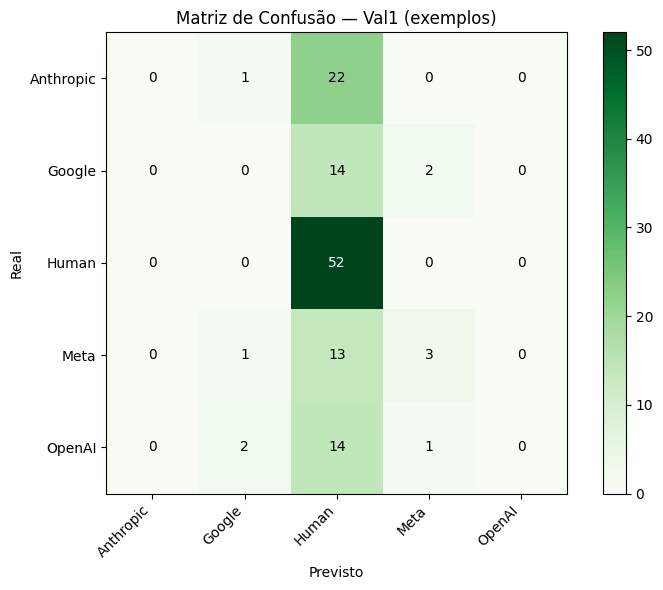


=== Val2 (subm1) ===
Accuracy: 0.3800

              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00        17
      Google       0.00      0.00      0.00        17
       Human       0.36      1.00      0.53        34
        Meta       0.67      0.22      0.33        18
      OpenAI       0.00      0.00      0.00        14

    accuracy                           0.38       100
   macro avg       0.21      0.24      0.17       100
weighted avg       0.24      0.38      0.24       100



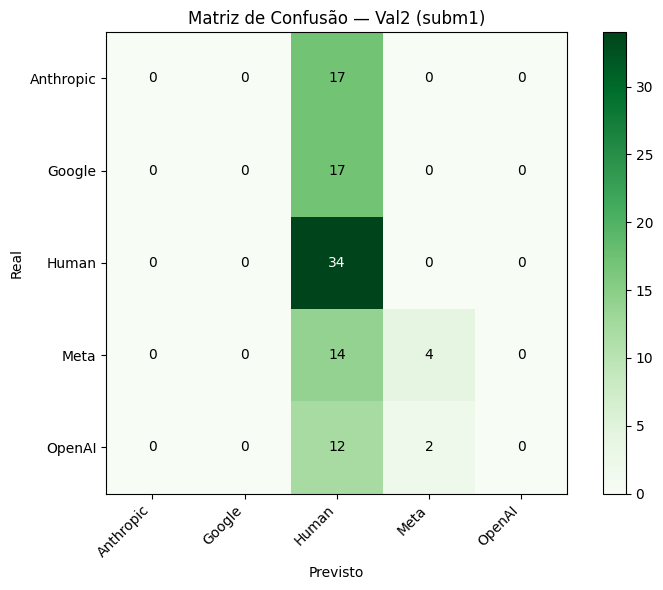

In [11]:
probs_val1, labels_val1 = full_evaluation(best_model, best_vectorizer, df_val1, 'Val1 (exemplos)')
probs_val2, labels_val2 = full_evaluation(best_model, best_vectorizer, df_val2, 'Val2 (subm1)')


## 7. Curva ROC (Macro Average)

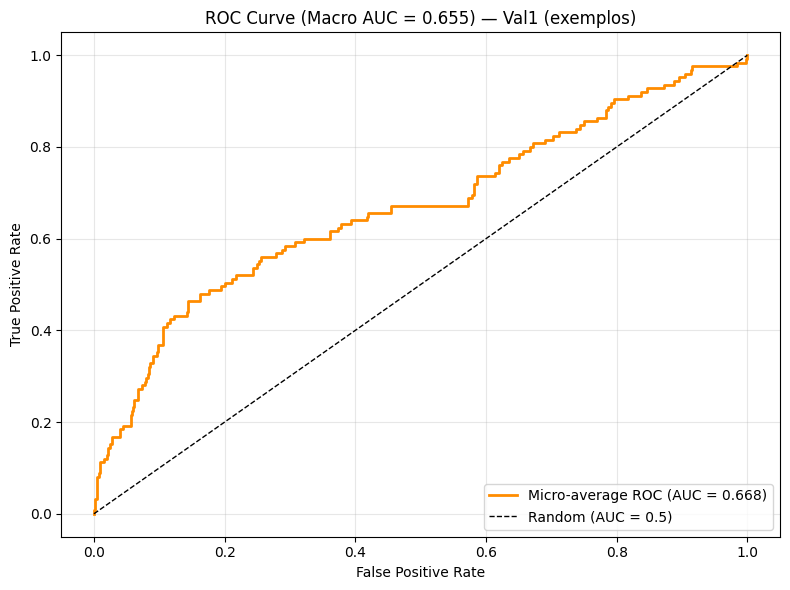

Val1 (exemplos): Micro AUC = 0.6684, Macro AUC = 0.6548


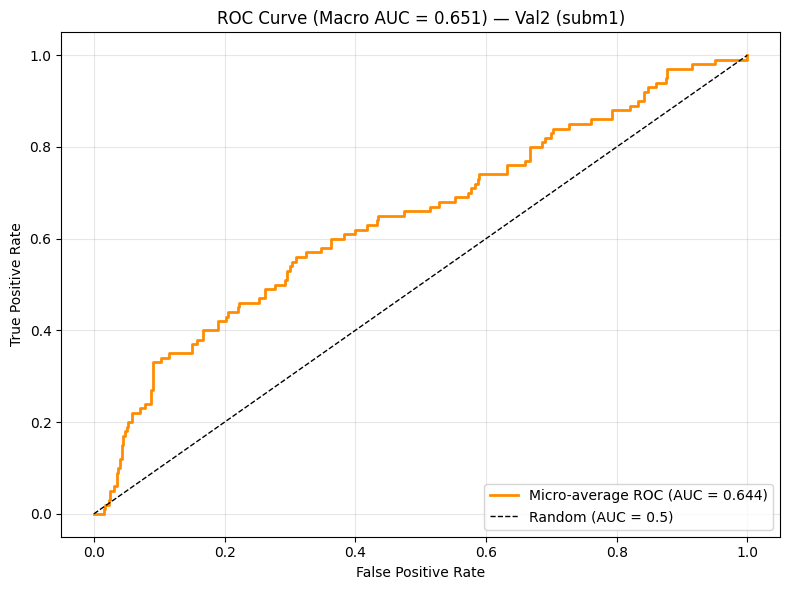

Val2 (subm1): Micro AUC = 0.6436, Macro AUC = 0.6510


In [12]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc

macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')


## 8. Conclusões

In [13]:
print('=' * 60)
print('CONCLUSÕES — Logistic Regression')
print('=' * 60)
print()

print('Melhor configuração:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["internal_val"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

os.makedirs(os.path.join(ROOT, 'saved_models'), exist_ok=True)
results_path = os.path.join(ROOT, 'data', 'processed', 'logreg_results.csv')
results_df.to_csv(results_path, index=False)
best_model.save(os.path.join(ROOT, 'saved_models', 'logistic_regression_final.npz'))
best_vectorizer.save(os.path.join(ROOT, 'saved_models', 'logistic_tfidf.pkl'))
print(f'Resultados guardados em {results_path}')
print('Modelo e vectorizer guardados em saved_models/')


CONCLUSÕES — Logistic Regression

Melhor configuração:
  max_words: 2000
  learning_rate: 0.1
  epochs: 900
Best Internal Validation Accuracy: 0.4524
Val1 AUC (macro): 0.6548
Val2 Accuracy: 0.3800
Val2 AUC (macro): 0.6510
Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/data/processed/logreg_results.csv
Modelo e vectorizer guardados em saved_models/
